# Difficulty Analysis of Mastermind Game Variants

 We investigate how the classic game of Mastermind changes in difficulty as we alter two key game parameters: the number of available colors, and the number of slots that make up the secret code. I built a custom Java Mastermind simulation and solver to simulate 100,000 games of each of 40+ game variants to measure the mean turns to win. Results reveal a non-linear crossover effect: in some reigons of parameter space, adding a new color adds more difficulty than increasing the code length, while in others, the opposite is true.

## Introduction
I created a Mastermind game as a pedagogical model project for my AP CS in Java class, as my students were frequently playing Wordle, but were universally unaware of this classic game of logic from which it derives. Designed as a model of code modularity, it expanded to include playable game variants. Later, an AI solver and assist was added, which keeps track of the remaining possible secret codes and selcts one at random. Finally it became a simulator and data-logger capable of seriously studying the game.

## Initial Hypothesis
The standard game of Mastermind has `C=6` possible colors in each of the `L=4` code slots. The number of possible secret codes in a game is $ C^L $, which works out to 1296 codes for the standard game. I expected initially that the difficulty would increase monotonically with the total number of possible codes, but quicky realized that adding a color strictly increases the difficulty of the game, whereas adding a digit increases the difficulty, but also increases the amount of information the guesser receives in a response. Therefore, I hypothesized that for any variant, adding a color to the game would increase the solver's mean turns to win _more_ than would adding a digit to the code.

## Data Sourcing and Preparation

First, we import the necessary libraries. Next, we load all .csv files from the /data directory, concatenate them into a single master DataFrame, and display the first 5 rows to verify the data is loaded correctly

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # We need this for the LogNorm
import seaborn as sns
import numpy as np

# Find all .csv files in the current directory
csv_files = glob.glob('data/*.csv')

# Load each CSV and store them in a list
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

# Concatenate all dataframes into one
master_df = pd.concat(dataframes, ignore_index=True)

print(f"Total simulations: {len(master_df)}")
master_df.head()

Total simulations: 3749835


,TurnsToWin,CodeLength,NumColors
0,1,2,10
1,1,2,10
2,1,2,10
3,1,2,10
4,1,2,10


With our raw data loaded, we'll aggregate it to get our key metrics for each unique `CodeLength` and `NumColors` combination. We need the mean, standard deviation, and count to assess both the performance of the solver and the rigor of our findings. To test the hypothesis that difficulty increases with the number of possible codes, we next add a column for the total number of codes in each game varaint. Finally, in order to perform our statistical validation, we calculate the Standard Error of the Mean and the 95% Confidence Interval. 

In [2]:

# Group by CodeLength and NumColors, then calculate mean, std dev, and count
difficulty_df = master_df.groupby(['CodeLength', 'NumColors']).agg(
    MeanTurnsToWin=('TurnsToWin', 'mean'),
    StdDevTurns=('TurnsToWin', 'std'),
    TrialCount=('TurnsToWin', 'count')
).reset_index()

# Add a new column 'TotalCodes' using the ** operator for exponentiation
difficulty_df['TotalCodes'] = difficulty_df['NumColors'] ** difficulty_df['CodeLength']

# Calculate the Standard Error of the Mean (SEM)
difficulty_df['SEM'] = difficulty_df['StdDevTurns'] / np.sqrt(difficulty_df['TrialCount'])

# Calculate the margin of error for the 95% confidence interval
difficulty_df['CI95_Margin'] = 1.96 * difficulty_df['SEM']

print("Aggregated Difficulty Data with calculated columns:")
print(difficulty_df.head())

Aggregated Difficulty Data with calculated columns:
   CodeLength  NumColors  MeanTurnsToWin  StdDevTurns  TrialCount  TotalCodes  \
0           2          3         2.47916     0.786481      100000           9   
1           2          4         2.94015     0.894369      100000          16   
2           2          5         3.39886     1.046777      100000          25   
3           2          6         3.87104     1.221845      100000          36   
4           2          7         4.35363     1.409502      100000          49   

        SEM  CI95_Margin  
0  0.002487     0.004875  
1  0.002828     0.005543  
2  0.003310     0.006488  
3  0.003864     0.007573  
4  0.004457     0.008736  


## Testing the Initial Hypothesis 
My first, simplest hypothesis was that difficulty scales monotonically with the total number of possible codes ($C^L$). To test this, I plotted the `MeanTurnsToWin` against the calculated `TotalCodes` ($C^L$) on a log scale.

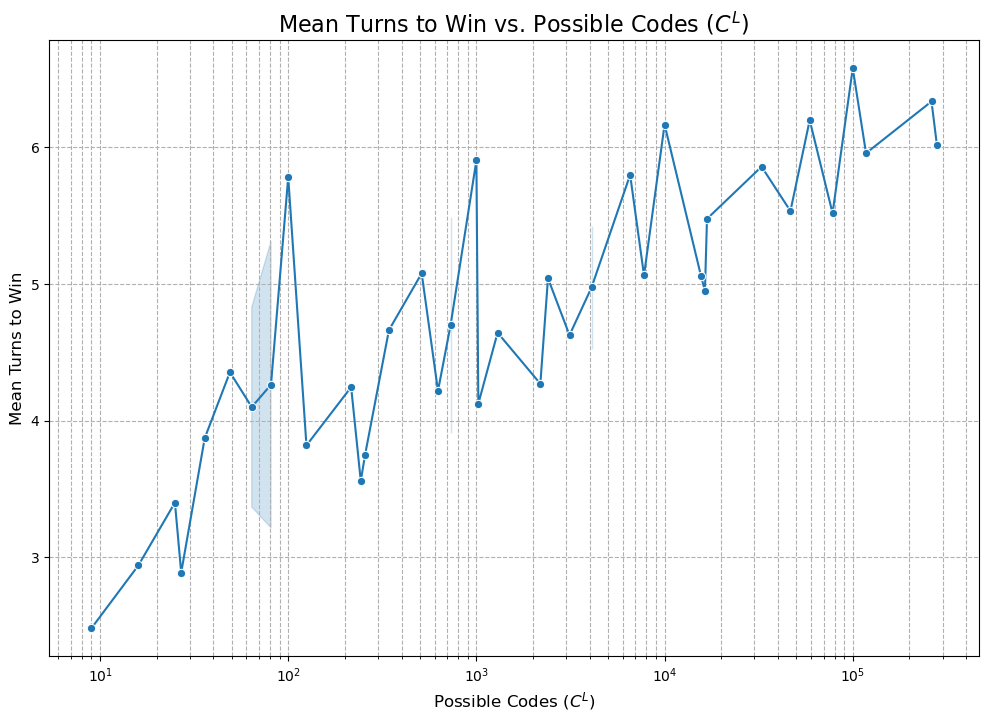

In [3]:
plt.figure(figsize=(12, 8))

# Draw the line plot without separating by hue
# marker='o' will place a dot at each (C^L, MeanTurns) point
sns.lineplot(data=difficulty_df, x='TotalCodes', y='MeanTurnsToWin', marker='o')

# Use a log scale on the x-axis
plt.xscale('log')

plt.title('Mean Turns to Win vs. Possible Codes ($C^L$)', fontsize=16)
plt.xlabel('Possible Codes $(C^L)$', fontsize=12)
plt.ylabel('Mean Turns to Win', fontsize=12)
plt.grid(True, which="both", ls="--") #Show the log grid as dotted lines

plt.show()


Plotting `MeanTurnsToWin` vs. `TotalCodes` immediately reveals a problem with the initial hypothesis. The relationship is clearly non-monotonic, with the difficulty (MeanTurnToWin) sometimes decreasing as the total number of codes increases.

This messiness is because $C^L$ is not a true single variable; it's a 2D parameter space. Different combinations (e.g., `L=4`, `C=3` and `L=2`, `C=9`) can result in the same $C^L$ value, but they are not equally difficult. (Hence the shaded area on the plot.) This plot is trying to collapse a 2D surface onto a 1D line.

## Visualizing the 2D Nature of the Problem

To visualize the true 2D nature of the problem, a much better approach is to plot the same data points but to draw curves of constant `L` and and constant `C`. The plot below shows both families of curves. Constant `CodeLength` curves are plotted as solid lines, and constant `NumColors` curves are dotted lines.

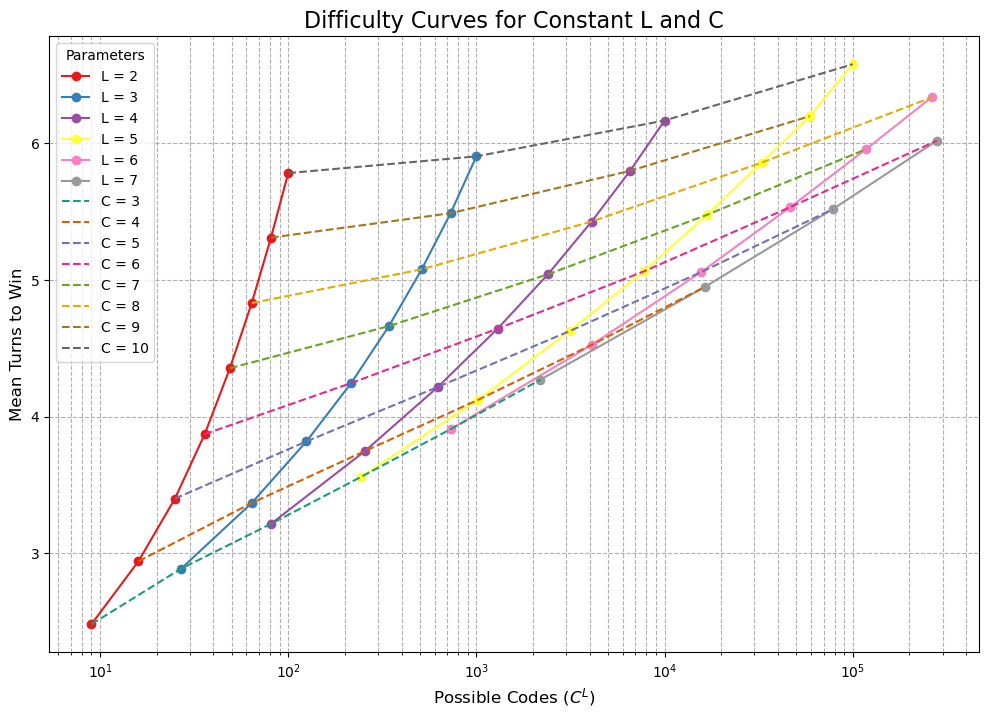

In [4]:

# Create a large figure to hold the plot
plt.figure(figsize=(12,8))

# --- Family 1: Constant CodeLength (Solid Lines) ---
# Get a color map for this family using 'Set1'
# This creates a list of colors, one for each unique CodeLength
colors_L = plt.cm.Set1(np.linspace(0, 1, difficulty_df['CodeLength'].nunique()))

#Find and sort a list of the unique values of CodeLength and enumerate to assign each unique value an index in order. Loop over these values.
for i, L in enumerate(sorted(difficulty_df['CodeLength'].unique())):
    # Get the subset of data for this CodeLength
    subset = difficulty_df[difficulty_df['CodeLength'] == L].sort_values('NumColors')
    plt.plot(
        subset['TotalCodes'], 
        subset['MeanTurnsToWin'], 
        marker='o',         # Use a circle marker
        linestyle='-',      # Use a solid line
        color=colors_L[i],  # Set the color
        label=f'L = {L}'    # Label for the legend
    )

# --- Family 2: Constant NumColors (Dashed Lines) ---
# Get a *different* color map for this family, 'Dark2';
colors_C = plt.cm.Dark2(np.linspace(0, 1, difficulty_df['NumColors'].nunique()))

#Find and sort a list of the unique values of NumColors and enumerate to assign each unique value an index in order. Loop over these values.
for i, C in enumerate(sorted(difficulty_df['NumColors'].unique())):
    # Get the subset of data for this NumColors
    subset = difficulty_df[difficulty_df['NumColors'] == C].sort_values('CodeLength')
    plt.plot(
        subset['TotalCodes'], 
        subset['MeanTurnsToWin'], 
        linestyle='--',    # Use a dashed line
        color=colors_C[i], # Set the Color
        label=f'C = {C}'    # Label for the legend
    )

# --- Formatting ---
plt.xscale('log')
plt.title("Difficulty Curves for Constant L and C", fontsize=16)
plt.xlabel('Possible Codes $(C^L)$', fontsize=12)
plt.ylabel('Mean Turns to Win', fontsize=12)
plt.grid(True, which="both", ls="--") # Show the log gris as dotted lines

# Add the legend.
plt.legend(title='Parameters',
           loc='upper left')

plt.show()

This plot, which has the exact same axes and data points as the previous plot, reveals the true, underlying difficulty structure. The 'mess' from the previous chart is resolved into a highly ordered pattern. We can clearly see two families of smooth, monotonic curves.

This confirms that `CodeLength` and `NumColors` are two independent factors that both monotonically increase difficulty. This proves that the true relationship is 2D and explains why the original 1D plot failed. 

## Comparing Difficulty Increase: Adding a Color vs Adding a Code Digit 

Now that we've established the 2D nature of the problem, this begs a new question: *How do these two difficulty factors compare?*
The constant `L` curves are in general, steeper than the constant `C` curves, lending credence to the refined hypothesis that adding a color makes the game harder than adding a code digit. But do these plots really confirm that this is always true? It's not obvious; it appears there are at least some regions where the dotted and solid curves are similarly steep. This leads to a new hypothesis: *there may be a crossover region in the (`L`, `C`) parameter space where the larger modifier of difficulty flips from one parameter to the other*.

To investigate this, we must visualize the 2D parameter space directly. We'll use a heatmap, as it will show us the 'difficulty surface' and allow us to look for this hypothesized crossover. The plot below shows MeanTurnsToWin for every game variant. We also display the 95% Confidence Interval (e.g., `± 0.01`) to show our precision.

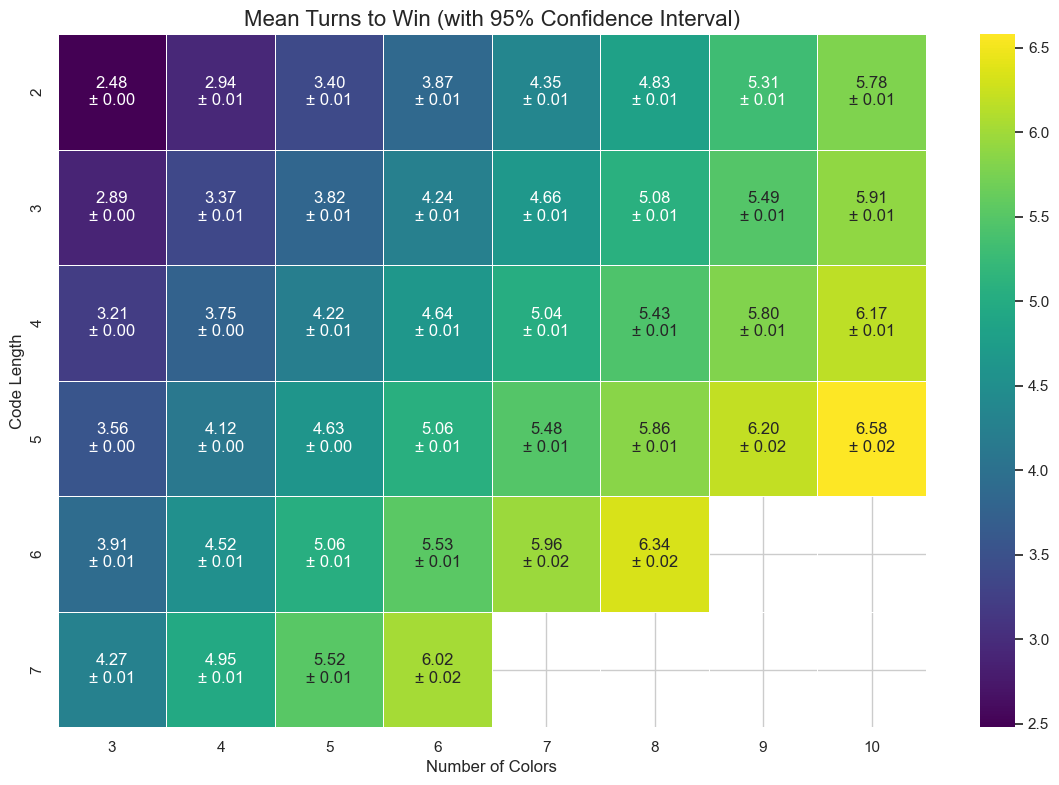

In [5]:
# Pivot the data to create a matrix suitable for a heatmap
heatmap_data = difficulty_df.pivot(index='CodeLength', columns='NumColors', values='MeanTurnsToWin')

# Pivot the CI margin data to make 'ci_margin_heatmap'
ci_margin_heatmap = difficulty_df.pivot(index='CodeLength', columns='NumColors', values='CI95_Margin')

sns.set_theme(style="whitegrid") #places a grid behind the cells of the heatmaps

# Create a new dataframe of the same shape to hold our text labels
annot_labels = heatmap_data.copy().astype(str)

# Loop through the data and create a formatted string for each cell
for r in heatmap_data.index:
    for c in heatmap_data.columns:
        mean_val = heatmap_data.loc[r, c]
        ci_val = ci_margin_heatmap.loc[r, c]
        if pd.notna(mean_val): # Check if the cell has a value
            annot_labels.loc[r, c] = f"{mean_val:.2f}\n\u00B1 {ci_val:.2f}" # \u00B1 is the plus-minus symbol
        else:
            annot_labels.loc[r, c] = '' # Leave empty cells empty

# Create the heatmap using our custom labels
plt.figure(figsize=(14, 9))
sns.heatmap(heatmap_data, annot=annot_labels, fmt='', cmap='viridis', linewidths=.5) # Use fmt='' because our labels are already strings
plt.title('Mean Turns to Win (with 95% Confidence Interval)', fontsize=16)
plt.xlabel('Number of Colors', fontsize=12)
plt.ylabel('Code Length', fontsize=12)
plt.savefig('mastermind_combined_heatmap.png', dpi=300)
plt.show()

The very small CI values show that our measurement of difficulty is highly precise and trustworthy. But it does not appear to be the case that adding a color is always more difficult than adding a digit. The heatmap incidates that there is a corssover and that, for some variants in the lower right, a new digit can indeed add more difficulty than a new color.

To better seek the crossover boundary, we'll calculate the marginal difficulty of taking the next step: at any point (`L`, `C`), is the game harder when you add a digit (`L=L+1`) or add a color (`C=C+1`)? We'll calculate the 'future-looking' differences for each parameter and plot them side-by-side.

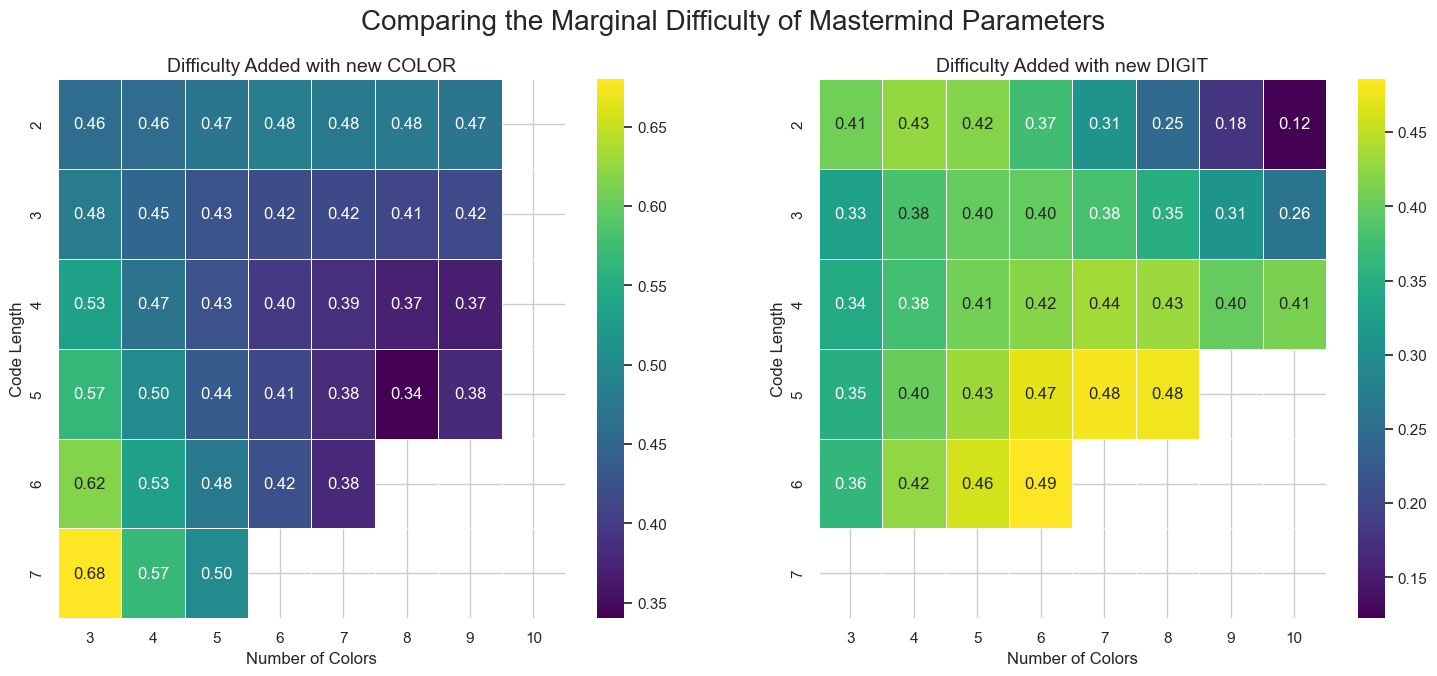

In [6]:
# We use our pivoted data in the 'heatmap_data' DataFrame from the last step.

# (Difficulty of adding one more digit, from this point)
length_difficulty_gradient = heatmap_data.diff(axis=0, periods=-1).mul(-1) #the periods and -1 multiplier ensure we look forward, not backwards

# (Difficulty of adding one more color, from this point)
color_difficulty_gradient = heatmap_data.diff(axis=1, periods=-1).mul(-1)


# Create the side-by-side visualizations
# Use a diverging colormap since we're looking at rates of change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comparing the Marginal Difficulty of Mastermind Parameters', fontsize=20)

sns.heatmap(color_difficulty_gradient, annot=True, fmt=".2f", cmap='viridis', linewidths=.5, ax=ax1)
ax1.set_title('Difficulty Added with new COLOR', fontsize=14)
ax1.set_xlabel('Number of Colors')
ax1.set_ylabel('Code Length')


sns.heatmap(length_difficulty_gradient, annot=True, fmt=".2f", cmap='viridis', linewidths=.5, ax=ax2)
ax2.set_title('Difficulty Added with new DIGIT', fontsize=14)
ax2.set_xlabel('Number of Colors')
ax2.set_ylabel('Code Length')


# Save the figure to file
plt.savefig('mastermind_gradient_comparison.png', dpi=300)

plt.show()

This next, final pair of heatmaps subtracts the two gradients.

The finding is plotted on the left: Blue cells show where adding a color is harder; Red cells show where adding a digit is harder. The greyer cells closest to zero in between them form the hypothesized crossover region. 

The Signal-to-Noise ratio is plotted on the right. To calculate the Confidence Intervals for these data, we add in quadrature the CI for the difficulty difference in each direction. SNR is obtained by dividing the value by the CI. Darker colors show lower SNR.


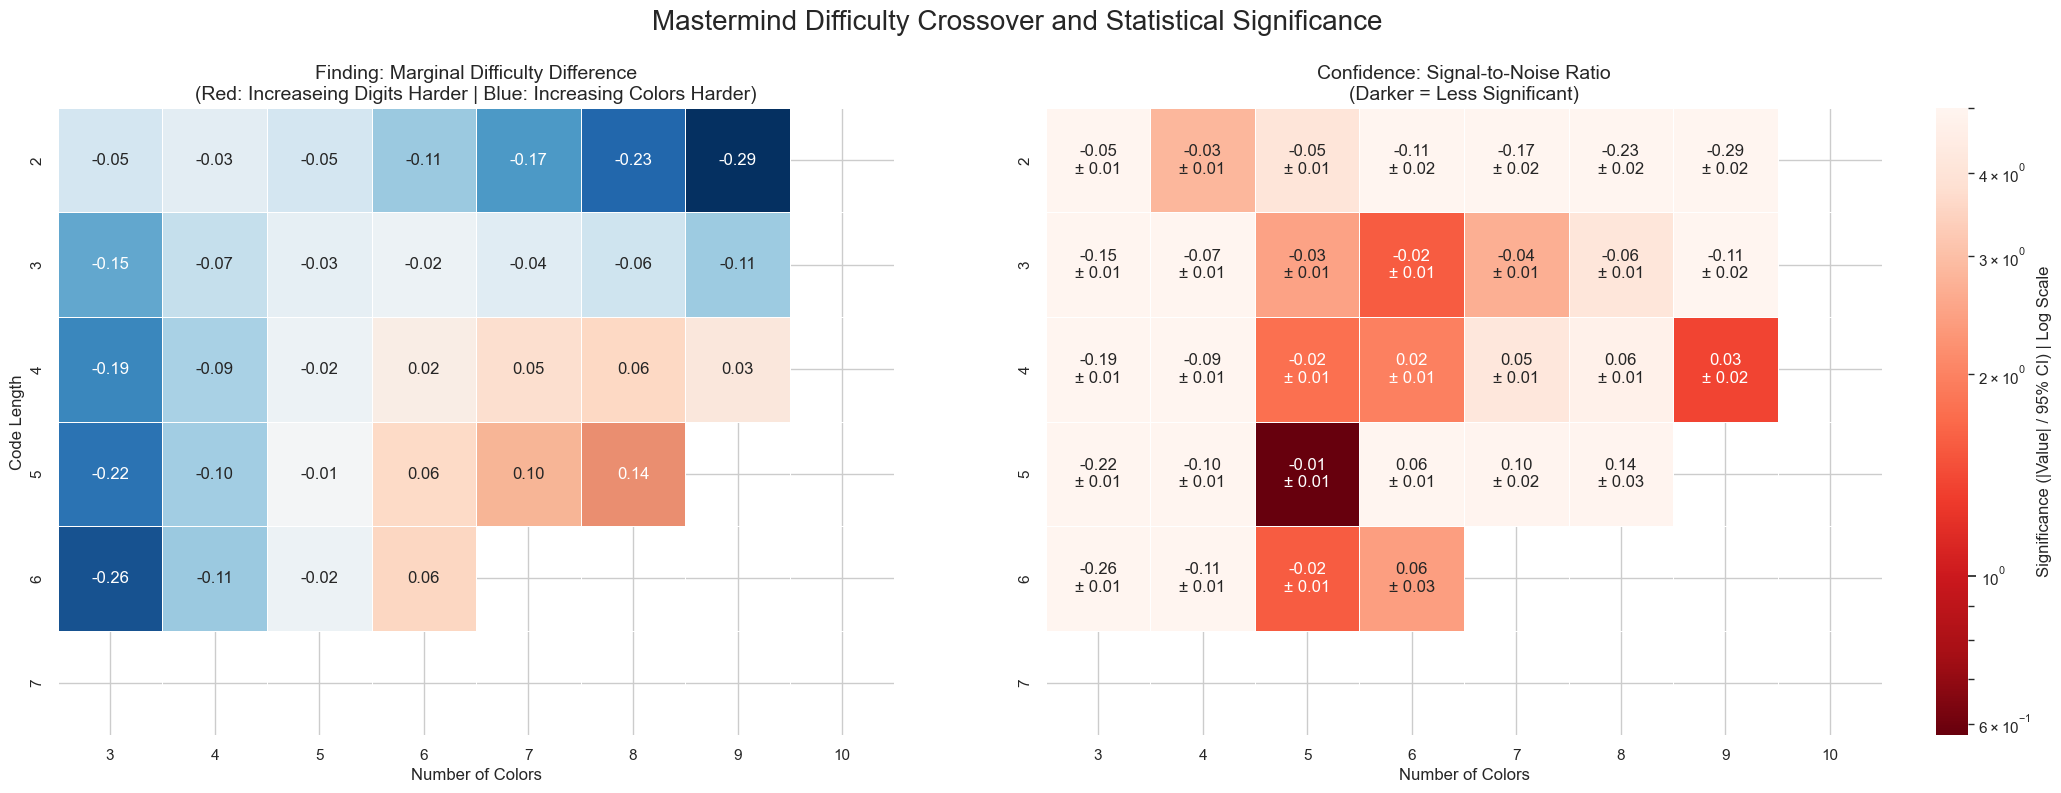

In [7]:
# Calculate the difference between the two gradients.
# A positive result means adding a digit is harder.
# A negative result means adding a color is harder.
crossover_df = length_difficulty_gradient - color_difficulty_gradient

# Calculate the 95% CI margin for each base measurement
difficulty_df['CI95_Margin'] = 1.96 * (difficulty_df['StdDevTurns'] / np.sqrt(difficulty_df['TrialCount']))
ci_margin_heatmap = difficulty_df.pivot(index='CodeLength', columns='NumColors', values='CI95_Margin')

# Propagate the uncertainty for our "future-looking" gradient calculation
# We need to add the uncertainties in quadrature.
# CI_crossover² = CI(L+1, C)² + CI(L, C+1)² + CI(L, C)² + CI(L, C)²
# This is because our value is (Mean[L+1,C] - Mean[L,C]) - (Mean[L,C+1] - Mean[L,C])
ci_margin_heatmap_sq = ci_margin_heatmap**2
ci_Lplus1_sq = ci_margin_heatmap_sq.shift(axis=0, periods=-1) # CI(L+1, C)²
ci_Cplus1_sq = ci_margin_heatmap_sq.shift(axis=1, periods=-1) # CI(L, C+1)²

# CI_crossover² = CI(L+1, C)² + CI(L, C+1)² + 2 * CI(L, C)²
ci_crossover_heatmap_sq = ci_Lplus1_sq + ci_Cplus1_sq + (2 * ci_margin_heatmap_sq)

# The final 95% CI margin for our crossover value
ci_crossover_heatmap = np.sqrt(ci_crossover_heatmap_sq)

# 2. Create the formatted text labels for annotation (e.g., "-0.05 ± 0.02")
annot_labels = crossover_df.copy().astype(str)
for r in crossover_df.index:
    for c in crossover_df.columns:
        main_val = crossover_df.loc[r, c]
        ci_val = ci_crossover_heatmap.loc[r, c]
        if pd.notna(main_val):
            annot_labels.loc[r, c] = f"{main_val:.2f}\n\u00B1 {ci_val:.2f}" # \u00B1 is the ± symbol
        else:
            annot_labels.loc[r, c] = '' # Leave empty cells empty


#Calculate signal-to-noise ratio so that we can color the cells accordingly.
statistical_significance = np.abs(crossover_df) / ci_crossover_heatmap

# Calculate the min and max for our log scale
# We'll cap the max at 5 (anything more is colored "very significant")
# We'll set the min to the lowest SNR in our data
vmin = statistical_significance.min().min()
vmax = 5 

# 2. Create the Logarithmic Normalizer
# We'll clip values outside our range
log_norm = mcolors.LogNorm(vmin=vmin, vmax=vmax, clip=True)

#--- Create the Side-by-Side Figure ---
# We'll make a wide figure (e.g., 22 inches) to fit both plots comfortably
fig, (ax1, ax2) = plt.subplots(
    1, 2, 
    figsize=(22, 8), 
    gridspec_kw={'width_ratios': [1, 1.1]} # We add 'gridspec_kw' to give the right plot 10% extra width to accomodate the color bar
)

# Add a main title for the entire figure
fig.suptitle('Mastermind Difficulty Crossover and Statistical Significance', fontsize=20)

# --- Plot 1, Finding: Marginal Difficulty Difference ---
sns.heatmap(
    crossover_df,
    annot=True,     # Annotate with the simple data value
    fmt=".2f",
    linewidths=.5,
    cmap='RdBu_r',
    center=0,
    cbar=False,     # No color bar
    ax=ax1,         # Plot on the left axis (ax1)
    square=True
)
ax1.set_title('Finding: Marginal Difficulty Difference\n(Red: Increaseing Digits Harder | Blue: Increasing Colors Harder)', fontsize=14)
ax1.set_xlabel('Number of Colors', fontsize=12)
ax1.set_ylabel('Code Length', fontsize=12)

# --- Plot 2, Signal to Noise Ratio ---
sns.heatmap(
    statistical_significance,
    annot=annot_labels, # Annotate with the 'value ± CI' strings
    fmt='',
    linewidths=.5,
    cmap="Reds_r",
    norm=log_norm,
    cbar_kws={'label': 'Significance (|Value| / 95% CI) | Log Scale'},
    ax=ax2,          # Plot on the right axis (ax2)
    square=True
)
ax2.set_title('Confidence: Signal-to-Noise Ratio\n(Darker = Less Significant)', fontsize=14)
ax2.set_xlabel('Number of Colors', fontsize=12)
ax2.set_ylabel('') # Remove redundant y-axis label

# --- Finalize and Show ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for the suptitle
plt.savefig('mastermind_final_comparison_plot.png', dpi=300)
plt.show()

## Interpreting the Crossover Map

The heatmap on the left successfully visualizes the 2D difficulty landscape and confirms our hypothesis that a crossover boundary exists. The plot clearly shows two distinct regions:

* **The Blue Region** (Negative Values): In this part of the parameter space (generally low `L` or `C`), adding a new color is the dominant driver of difficulty. This is consistent with our refined hypothesis that the information gained from adding a digit to the code mitigates some of the increased difficulty.

* **The Red Region** (Positive Values): In this area (generally high `L` and `C`), the effect has flipped. The exponential growth of the search space ($C^L$) has made adding a new digit, and therefore many new code possibilities, the more significant challenge.

An interesting finding is the *shape of the crossover boundary*. It is not a simple, straight line. It appears that the boundray is a curve that delineates the region with large enough values of `C` and `L` to make adding a digit the more difficult option.

A final interesting observation is that the standard game (`C=6`,`L=4`) lies right at the 'corner' of the crossover, perhaps indicating that the standard game is in some respects well-balanced.  


## Statistical Validation: Proving the Crossover

The plot on the right is our Significance Map showing our confidence in that finding.

By definition, the crossover is where the signal (the difference) approaches zero. This map allows us to distinguish a real, measured crossover from simple statistical noise.

The dark red cells, where the Signal-to-Noise Ratio (SNR) is low, are the measured boundary. The fact that they are bordered by light-colored cells with high statistical significance (e.g., at `L=3`, `C=9` or `L=5`, `C=8`) is our proof that the crossover is a real, measured feature of the system.

## Conclusion & Next Steps

We found, to high precision, the mean turns to win for many variants of Mastermind. We also successfully compared the difficulty changes in adding a color versus adding a digit, finding two distinct regions in the parameter space, separated by a crossover boundary. The crossover is not a simple line but a curve. This boundary is a fundamental property of the game.

Next steps could include taking more data on some variants to improve precision further, especially where the SNR is low. It would also be interesting to continue the study with even more variants.

Additionally, the solver I created is very good, but not perfectly optimal. An optimal solver would more intelligently select a code, basing the decision on maximizing the information to be gained from the response. Initial forays into this have shown long computational times per game, making a precise study like this one logistically difficult.